<a href="https://colab.research.google.com/github/DiogoBotton/Computer_Vision_Medicine/blob/dev/src/model/chexpert_cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Modelo de classificação para detectar anomalias presentes em radiográfias de tórax

Iremos utilizar o dataset adquirido na fase 1 chamado `CheXpert-v1.0-small`, é possível encontrá-lo no Kaggle [clicando aqui](https://www.kaggle.com/datasets/ashery/chexpert).

### Importação das bibliotecas

In [ ]:
!pip install iterative-stratification

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras import Sequential
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import BinaryAccuracy, Precision, Recall, AUC
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Layer, GlobalMaxPooling2D, Conv2D, MaxPooling2D, Input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.applications.inception_v3 import preprocess_input
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score, precision_score, recall_score, roc_auc_score, average_precision_score
from sklearn.preprocessing import label_binarize

# Função de divisão de dados para datasets multilabel (servirá para fazer amostragem estratificada multilabel)
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit
from sklearn.utils import indexable, _safe_indexing
from sklearn.utils.validation import _num_samples
from sklearn.model_selection._split import _validate_shuffle_split
from itertools import chain

import shutil
import cv2
from pathlib import Path
import os
import zipfile
from datetime import datetime

### Configuração do Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
ZIP_PATH = '/content/drive/MyDrive/Datasets/CheXpert-v1.0-small.zip'
EXTRACT_PATH = '/content/CheXpert-v1.0-small'

In [ ]:
os.makedirs(EXTRACT_PATH, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
  zip_ref.extractall(EXTRACT_PATH)

print('Dataset descompactado em: ', EXTRACT_PATH)

Dataset descompactado em:  /content/CheXpert-v1.0-small


### Exploração dos dados

In [ ]:
DATA_DIR = Path('/content/CheXpert-v1.0-small')

In [ ]:
df_train = pd.read_csv(os.path.join(DATA_DIR, "train.csv"))
df_test = pd.read_csv(os.path.join(DATA_DIR, "valid.csv"))

In [ ]:
print('Quantidade de imagens de treino no total:', len(df_train))
print('Quantidade de imagens de teste no total:', len(df_test))

Quantidade de imagens de treino no total: 223414
Quantidade de imagens de teste no total: 234


 Existem 14 labels distintas neste dataset, dentre eles:
 - No Finding
 - Enlarged Cardiomediastinum
 - Cardiomegaly
 - Lung Opacity
 - Lung Lesion
 - Edema
 - Consolidation
 - Pneumonia
 - Atelectasis
 - Pneumothorax
 - Pleural Effusion
 - Pleural Other
 - Fracture
 - Support Devices

 Cada célula nessas colunas de rótulos pode ter valores de incerteza (-1), presença (1) ou ausência (0). Para simplificar o pré-processamento, poderíamos tratar valores -1 como 0 (não presente), reduzindo a complexidade na criação do modelo de CNN. Além disso, como esse dataset é multi-label, cada paciente pode ter múltiplas condições simultaneamente, o que é importante considerar no treinamento.

 Assim como, também há dados que fazem referencia a um mesmo paciente, ou seja, há mais de um exame por paciente, como por exemplo, frontais e laterais ou mais de um estudo por paciente com as mesmas perspectivas, isto é, pode ser que um paciente tenha dois estudos diferentes mas com vistas iguais, por exemplo, um paciente que tirou raio x do tórax da perspectiva frontal duas vezes com um intervalo de tempo entre os exames.

In [ ]:
df_train.head()

,Path,Sex,Age,Frontal/Lateral,AP/PA,No Finding,Enlarged Cardiomediastinum,Cardiomegaly,Lung Opacity,Lung Lesion,Edema,Consolidation,Pneumonia,Atelectasis,Pneumothorax,Pleural Effusion,Pleural Other,Fracture,Support Devices
0,CheXpert-v1.0-small/train/patient00001/study1/...,Female,68,Frontal,AP,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,1.0
1,CheXpert-v1.0-small/train/patient00002/study2/...,Female,87,Frontal,AP,NaN,NaN,-1.0,1.0,NaN,-1.0,-1.0,NaN,-1.0,NaN,-1.0,NaN,1.0,NaN
2,CheXpert-v1.0-small/train/patient00002/study1/...,Female,83,Frontal,AP,NaN,NaN,NaN,1.0,NaN,NaN,-1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN
3,CheXpert-v1.0-small/train/patient00002/study1/...,Female,83,Lateral,NaN,NaN,NaN,NaN,1.0,NaN,NaN,-1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN
4,CheXpert-v1.0-small/train/patient00003/study1/...,Male,41,Frontal,AP,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN


In [ ]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 223414 entries, 0 to 223413
Data columns (total 19 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Path                        223414 non-null  object 
 1   Sex                         223414 non-null  object 
 2   Age                         223414 non-null  int64  
 3   Frontal/Lateral             223414 non-null  object 
 4   AP/PA                       191027 non-null  object 
 5   No Finding                  22381 non-null   float64
 6   Enlarged Cardiomediastinum  44839 non-null   float64
 7   Cardiomegaly                46203 non-null   float64
 8   Lung Opacity                117778 non-null  float64
 9   Lung Lesion                 11944 non-null   float64
 10  Edema                       85956 non-null   float64
 11  Consolidation               70622 non-null   float64
 12  Pneumonia                   27608 non-null   float64
 13  Atelectasis   

### Pré-processamento

Primeiramente, iremos simplificar as labels com -1 (incerteza) para 0 (ausência).

In [ ]:
# Definição de algumas constantes
BATCH_SIZE = 32
HEIGHT, WIDTH, _ = (299,299,3)
SEED = 42

Iremos agora separar apenas um exemplo por paciente, para não cometermos o erro de ter mais de uma imagem por paciente. Iremos fazer isto pois em seguida iremos derivar o conjunto de validação a partir do conjunto de treino, portanto, não poderá ter vazamento de exames de um mesmo paciente do conjunto de treino para o conjunto de validação.

Primeiramente, iremos incluir uma coluna identificadora do paciente a partir do Path.

In [ ]:
df_train["PatientID"] = df_train["Path"].str.extract(r'(patient\d+)')

In [ ]:
df_train[["Path","PatientID"]].head()

,Path,PatientID
0,CheXpert-v1.0-small/train/patient00001/study1/...,patient00001
1,CheXpert-v1.0-small/train/patient00002/study2/...,patient00002
2,CheXpert-v1.0-small/train/patient00002/study1/...,patient00002
3,CheXpert-v1.0-small/train/patient00002/study1/...,patient00002
4,CheXpert-v1.0-small/train/patient00003/study1/...,patient00003


Filtra para ter apenas imagens frontais tiradas de costas (raio entra pelas costas e sai pelo peito). Normalmente este tipo de perspectiva tem mais qualidade na imagem de Raio X.

In [ ]:
df_train_front_pa = df_train[(df_train["Frontal/Lateral"].str.lower() == "frontal") & (df_train["AP/PA"].str.lower() == "pa")].copy() # Realiza a cópia do dataset original para não dar problema de referencia

In [ ]:
df_train_front_pa[["Path","Frontal/Lateral","AP/PA"]].head()

,Path,Frontal/Lateral,AP/PA
5,CheXpert-v1.0-small/train/patient00004/study1/...,Frontal,PA
7,CheXpert-v1.0-small/train/patient00005/study1/...,Frontal,PA
16,CheXpert-v1.0-small/train/patient00009/study1/...,Frontal,PA
18,CheXpert-v1.0-small/train/patient00010/study1/...,Frontal,PA
20,CheXpert-v1.0-small/train/patient00011/study13...,Frontal,PA


Adquire apenas um exame por paciente (aleatóriamente).

In [ ]:
df_train_unique_patient = (
    df_train_front_pa
    .groupby("PatientID")
    .sample(n=1, random_state=SEED)
    .reset_index(drop=True)
)

In [ ]:
print("Nova quantidade de imagens no treino:", len(df_train_unique_patient))

Nova quantidade de imagens no treino: 20543


Agora faremos a mesma coisa com o conjunto de teste, porém para este caso, não há necessidade de ter apenas um exemplo por paciente, apenas manter a coerência de ter apenas imagens frontais do tipo PA.

In [ ]:
df_test_front_pa = df_test[(df_test["Frontal/Lateral"].str.lower() == "frontal") & (df_test["AP/PA"].str.lower() == "pa")].copy()

In [ ]:
df_test_front_pa[["Path","Frontal/Lateral","AP/PA"]].head()

,Path,Frontal/Lateral,AP/PA
1,CheXpert-v1.0-small/valid/patient64542/study1/...,Frontal,PA
7,CheXpert-v1.0-small/valid/patient64547/study1/...,Frontal,PA
8,CheXpert-v1.0-small/valid/patient64547/study1/...,Frontal,PA
13,CheXpert-v1.0-small/valid/patient64551/study1/...,Frontal,PA
19,CheXpert-v1.0-small/valid/patient64556/study1/...,Frontal,PA


In [ ]:
print("Nova quantidade de imagens no teste:", len(df_test_front_pa))

Nova quantidade de imagens no teste: 33


In [ ]:
label_cols = ["No Finding","Enlarged Cardiomediastinum","Cardiomegaly","Lung Opacity","Lung Lesion","Edema","Consolidation","Pneumonia","Atelectasis","Pneumothorax","Pleural Effusion","Pleural Other","Fracture","Support Devices"]

In [ ]:
# Substitui todos os -1 das células por 0
df_train_unique_patient[label_cols] = df_train_unique_patient[label_cols].replace(-1, 0)
df_test_front_pa[label_cols] = df_test_front_pa[label_cols].replace(-1, 0)

# Substitui todos os NaN por 0
df_train_unique_patient[label_cols] = df_train_unique_patient[label_cols].fillna(0)
df_test_front_pa[label_cols] = df_test_front_pa[label_cols].fillna(0)

# Encurtado
# df_train_unique_patient[label_cols] = df_train_unique_patient[label_cols].fillna(0).replace(-1, 0)

df_train_unique_patient.head()

,Path,Sex,Age,Frontal/Lateral,AP/PA,No Finding,Enlarged Cardiomediastinum,Cardiomegaly,Lung Opacity,Lung Lesion,Edema,Consolidation,Pneumonia,Atelectasis,Pneumothorax,Pleural Effusion,Pleural Other,Fracture,Support Devices,PatientID
0,CheXpert-v1.0-small/train/patient00004/study1/...,Female,20,Frontal,PA,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,patient00004
1,CheXpert-v1.0-small/train/patient00005/study1/...,Male,33,Frontal,PA,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,patient00005
2,CheXpert-v1.0-small/train/patient00009/study1/...,Male,76,Frontal,PA,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,patient00009
3,CheXpert-v1.0-small/train/patient00010/study1/...,Female,50,Frontal,PA,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,patient00010
4,CheXpert-v1.0-small/train/patient00011/study13...,Female,22,Frontal,PA,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,patient00011


Agora, iremos realizar uma amostragem estratificada dos dados para datasets multilabel (nosso caso) para não ser necessário pegar todos os mais de 200 mil exemplos de Raio X de tórax para esse estudo de caso.

**Edit.** Antes de percebermos que o dataset havia mais de um exame por paciente, tivemos a necessidade de fazer a estratificação para resolver o caso mencionado acima. Porém, o dataset ficou bem menor após realizarmos o filtro por imagens **frontais**, **PA**(Posteroanterior - feixe entra pelas costas e sai pelo peito) e filtrar apenas um exame por paciente. Portanto, não seria obrigatório realizar essa amostragem estratificada, porém mantivemos o código com este processo para caso algum dia seja necessário ter um exemplo de como realizar este mesmo processo em alguma outra situação.

In [ ]:
# Adquire todos os Paths (caminhos de imagens) e armazena na variável X
X = df_train_unique_patient["Path"].values.reshape(-1,1)

# Aqui será todas as labels, cada imagem tem uma lista de labels
y = df_train_unique_patient[label_cols].values

In [ ]:
X[:5]

array([['CheXpert-v1.0-small/train/patient00004/study1/view1_frontal.jpg'],
       ['CheXpert-v1.0-small/train/patient00005/study1/view1_frontal.jpg'],
       ['CheXpert-v1.0-small/train/patient00009/study1/view1_frontal.jpg'],
       ['CheXpert-v1.0-small/train/patient00010/study1/view1_frontal.jpg'],
       ['CheXpert-v1.0-small/train/patient00011/study13/view1_frontal.jpg']],
      dtype=object)

In [ ]:
y[:5]

array([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 1., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]])

Agora iremos dividir o dataset de forma estratificada para datasets multilabel com uma função customizada.

Fonte: https://github.com/scikit-multilearn/scikit-multilearn/issues/202

In [ ]:
def multilabel_train_test_split(*arrays,
                                test_size=None,
                                train_size=None,
                                random_state=None,
                                shuffle=True,
                                stratify=None):
    """
    Train test split for multilabel classification. Uses the algorithm from:
    'Sechidis K., Tsoumakas G., Vlahavas I. (2011) On the Stratification of Multi-Label Data'.
    """
    if stratify is None:
        return train_test_split(*arrays, test_size=test_size,train_size=train_size,
                                random_state=random_state, stratify=None, shuffle=shuffle)

    assert shuffle, "Stratified train/test split is not implemented for shuffle=False"

    n_arrays = len(arrays)
    arrays = indexable(*arrays)
    n_samples = _num_samples(arrays[0])
    n_train, n_test = _validate_shuffle_split(
        n_samples, test_size, train_size, default_test_size=0.25
    )
    cv = MultilabelStratifiedShuffleSplit(test_size=n_test, train_size=n_train, random_state=123)
    train, test = next(cv.split(X=arrays[0], y=stratify))

    return list(
        chain.from_iterable(
            (_safe_indexing(a, train), _safe_indexing(a, test)) for a in arrays
        )
    )

Utiliza a função acima para separar apenas 10% do dataset de + de 200 mil dados (fica com aproximadamente 22k).

**Edit.** Alteramos o código para pegar 100% dos dados, pois como o edit anterior mencionou o processo que fizemos para evitar o vazamento de dados de um mesmo paciente entre os datasets de treino, validação e teste já reduziu drasticamente o comprimento do dataset (20k~), então não é necessário realizar esse procedimento após isso. Como dito anteriormente, iremos manter essa parte do código para ter um exemplo de como realizar a amostragem estratificada para datasets multilabels caso seja necessário no futuro.

In [ ]:
#X_small, _, y_small, _ = multilabel_train_test_split(X, y, stratify=y, test_size=0.90, random_state=SEED) # Apenas ficará com 10% dos dados

Agora a partir do dataset menor divide entre treino e validação.

In [ ]:
#X_train, X_val, _, y_val = multilabel_train_test_split(X_small, y_small, stratify=y_small, test_size=0.10, random_state=SEED)
X_train, X_val, _, y_val = multilabel_train_test_split(X, y, stratify=y, test_size=0.10, random_state=SEED)

Define o novo dataset de treino (menor).

In [ ]:
df_train_small = df_train_unique_patient[df_train_unique_patient["Path"].isin(X_train.ravel())] # A função ravel() transforma um array multidimensional em unidimensional

A partir do dataset de validação, divide uma parte para somar ao dataset original de teste.

In [ ]:
X_val_split, X_test_split, _, _ = multilabel_train_test_split(X_val, y_val, stratify=y_val, test_size=0.10, random_state=SEED)

Define o conjunto de validação e incrementa novos dados no conjunto de teste.

In [ ]:
df_val_small = df_train_unique_patient[df_train_unique_patient["Path"].isin(X_val_split.ravel())]
df_test_small = df_train_unique_patient[df_train_unique_patient["Path"].isin(X_test_split.ravel())]

# Concatena o dataset de teste original com uma parte dividida do conjunto de validação
df_test_new = pd.concat([df_test_front_pa, df_test_small], ignore_index=True)

In [ ]:
print('Quantidade de imagens:\n')
print('Treino:', len(df_train_small))
print('Validação:', len(df_val_small))
print('Teste:', len(df_test_new))

Quantidade de imagens:

Treino: 18488
Validação: 1849
Teste: 239


A função customizada de pré-processamento das imagens abaixo é realizada antes de enviá-las ao modelo de rede neural. Aplica o CLAHE (Contrast Limited Adaptive Histogram Equalization), uma técnica de equalização adaptativa de histograma. Esta técnica melhora o contraste local da imagem sem amplificar ruído em excesso, ideal para realçar detalhes sutis em regiões com pouca variação de intensidade, como tecidos em imagens médicas.

No final passa pela função preprocess_input (do próprio modelo InceptionV3), que normaliza os valores conforme o modelo base (InceptionV3). Pode normalizar as imagens de 0 a 1 ou -1 a 1 dependendo do modelo.

In [ ]:
def custom_processing(img):
    img_uint8 = img.astype(np.uint8)
    img_gray = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2GRAY)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    equalized = clahe.apply(img_gray)
    equalized_rgb = cv2.merge([equalized, equalized, equalized])

    processed = preprocess_input(equalized_rgb.astype(np.float32))
    return processed

In [ ]:
datagen = ImageDataGenerator(
    preprocessing_function=custom_processing
)

O parâmetro `class_mode` da função `flow_from_dataframe` deve ser definido como *raw*. Desta forma os rótulos serão uma matriz de shape (batch_size, num_labels) com 0s e 1s (classificação multilabel).

In [ ]:
train_generator = datagen.flow_from_dataframe(
    dataframe=df_train_small,
    x_col='Path',
    y_col=label_cols,
    target_size=(HEIGHT, WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='raw',
    shuffle=True,
    seed=SEED
)

val_generator = datagen.flow_from_dataframe(
    dataframe=df_val_small,
    x_col='Path',
    y_col=label_cols,
    target_size=(HEIGHT, WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='raw',
    shuffle=False
)

test_generator = datagen.flow_from_dataframe(
    dataframe=df_test_new,
    x_col='Path',
    y_col=label_cols,
    target_size=(HEIGHT, WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='raw',
    shuffle=False
)

Found 18488 validated image filenames.
Found 1849 validated image filenames.
Found 239 validated image filenames.


In [ ]:
y_true_test = test_generator.labels  # rótulos verdadeiros do conjunto de teste
y_true_val = val_generator.labels  # rótulos verdadeiros do conjunto de validação
y_true_train = train_generator.labels  # rótulos verdadeiros do conjunto de treino

Abaixo apenas estamos verificando se para cada conjunto de dados (treino, validação e teste) há pelo menos um ou mais exemplos positivos por classe nos conjuntos. Foi realizado acima uma divisão mais estratégica para que nenhum conjunto tenha 0 exemplos positivos em alguma classe específica (basicamente, foi o processo de acrescentar ao conjunto de teste um pouco dos dados de validação).

In [ ]:
import numpy as np

print("Positivos por classe no teste:")
print(np.sum(y_true_test, axis=0))

print("Negativos por classe no teste:")
print(y_true_test.shape[0] - np.sum(y_true_test, axis=0))

Positivos por classe no teste:
[57. 11. 21. 73. 14. 13. 10.  9. 26. 12. 53.  6. 10. 57.]
Negativos por classe no teste:
[182. 228. 218. 166. 225. 226. 229. 230. 213. 227. 186. 233. 229. 182.]


In [ ]:
print("Positivos por classe na validação:")
print(np.sum(y_true_val, axis=0))

print("Negativos por classe na validação:")
print(y_true_val.shape[0] - np.sum(y_true_val, axis=0))

Positivos por classe na validação:
[387.  85. 175. 580. 129. 108.  87.  79. 196.  87. 453.  58.  90. 445.]
Negativos por classe na validação:
[1462. 1764. 1674. 1269. 1720. 1741. 1762. 1770. 1653. 1762. 1396. 1791.
 1759. 1404.]


In [ ]:
print("Positivos por classe no treino:")
print(np.sum(y_true_train, axis=0))

print("Negativos por classe no treino:")
print(y_true_train.shape[0] - np.sum(y_true_train, axis=0))

Positivos por classe no treino:
[3866.  849. 1750. 5803. 1287. 1081.  877.  796. 1964.  874. 4530.  572.
  896. 4454.]
Negativos por classe no treino:
[14622. 17639. 16738. 12685. 17201. 17407. 17611. 17692. 16524. 17614.
 13958. 17916. 17592. 14034.]


### Visualização das imagens do primeiro batch do gerador de treinamento

In [ ]:
x_batch, y_batch = next(train_generator)
print("Imagens:", x_batch.shape) # (batch_size, height, width, canais)
print("Labels:", y_batch.shape) # (batch_size, número de labels)
print("Exemplo de label:", y_batch[0]) # [labels] 0s e 1s (14 labels)

Imagens: (32, 299, 299, 3)
Labels: (32, 14)
Exemplo de label: [0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]


In [ ]:
# Pega os índices correspondentes às imagens atuais
batch_indices = train_generator.index_array[:len(x_batch)]

# Busca os caminhos no dataframe
image_paths = df_train.iloc[batch_indices]['Path'].values

Imagens originais do primeiro batch.

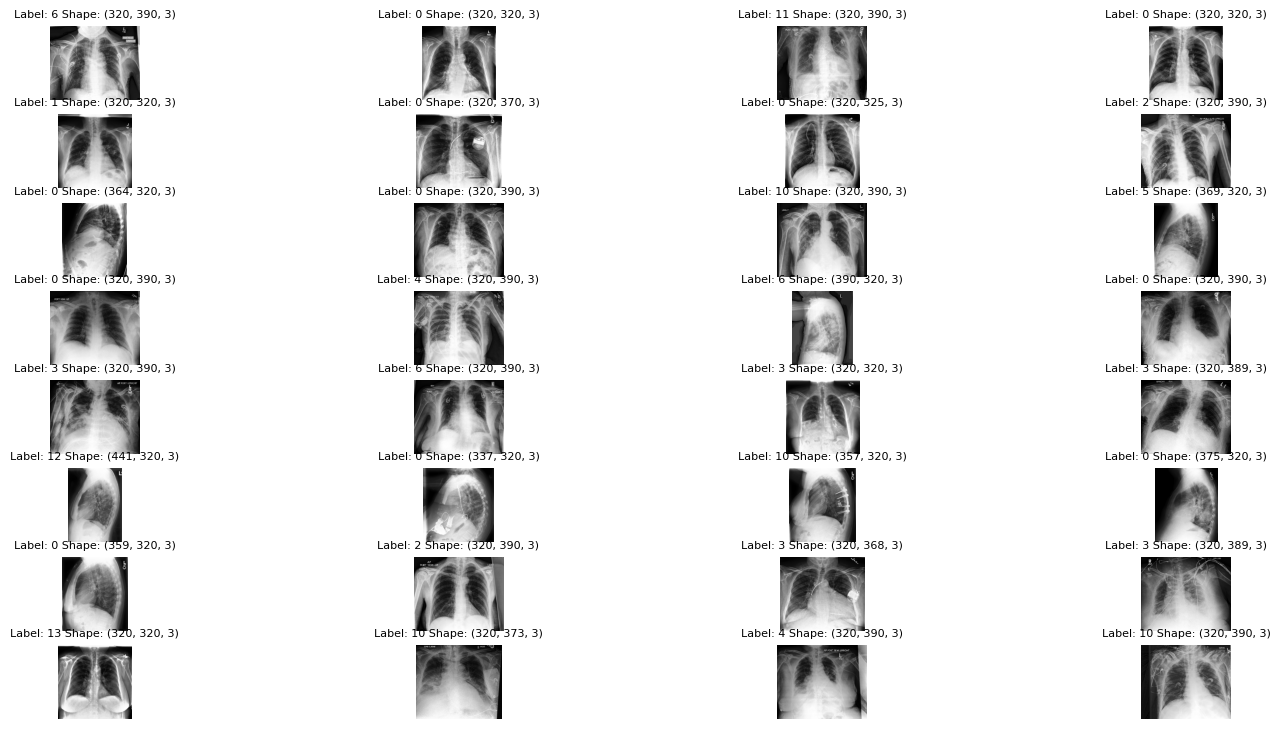

In [ ]:
plt.figure(figsize=(18,9))
for i in range(len(x_batch)):
    plt.subplot(8, 4, i+1)
    img = cv2.imread(image_paths[i])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img)
    plt.title(f"Label: {y_batch[i].argmax()} Shape: {img.shape}", fontsize=8) # argmax adquire o maior valor do array (pois o label é categórico one-hot encoding)
    plt.axis('off')

Visualização das imagens processadas no primeiro batch.

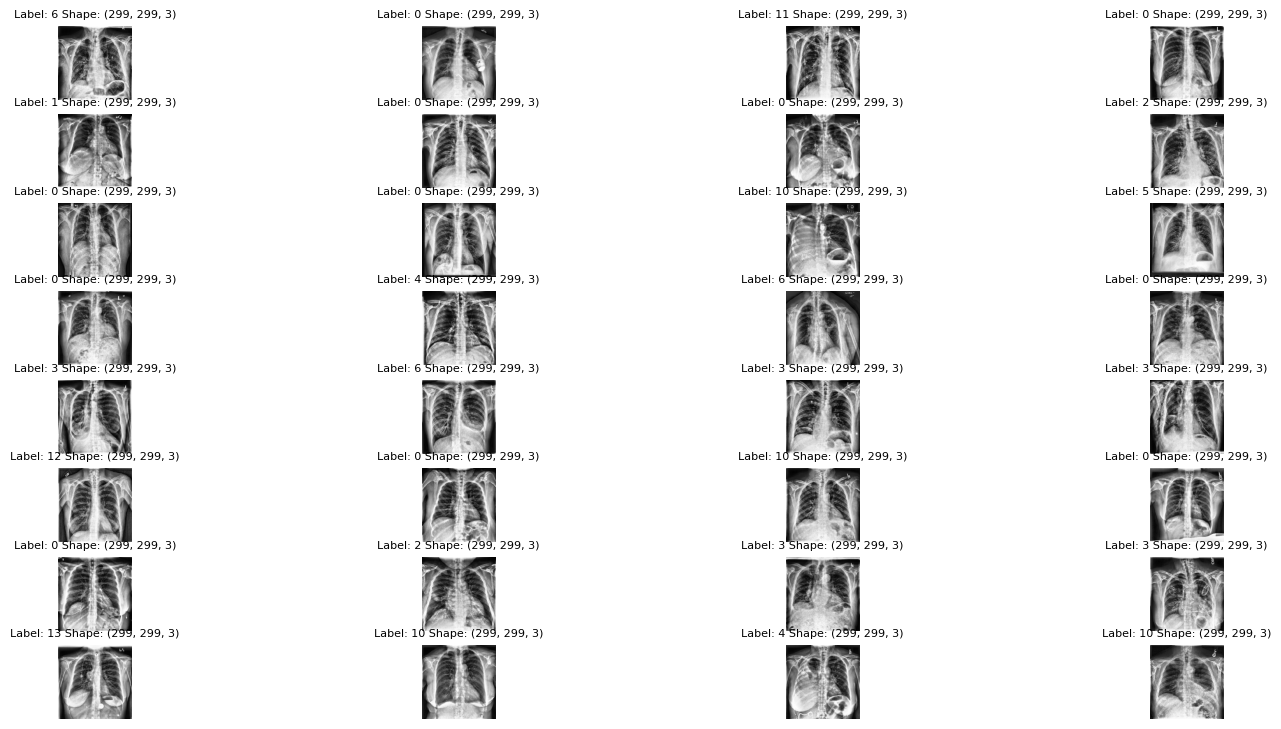

In [ ]:
plt.figure(figsize=(18,9))
for i in range(len(x_batch)):
    plt.subplot(8, 4, i+1)
    img_display = (x_batch[i] + 1) / 2
    plt.imshow(img_display)
    plt.title(f"Label: {y_batch[i].argmax()} Shape: {x_batch[i].shape}", fontsize=8) # argmax adquire o maior valor do array (pois o label é categórico one-hot encoding)
    plt.axis('off')

### CNN treinada do zero

In [ ]:
raw_model = Sequential([
    Input(shape=(HEIGHT, WIDTH, 3)),

    Conv2D(32, (3,3), activation='relu'), # Adicionando camada convolucional com 32 filtros de 3x3 pixels
    MaxPooling2D(pool_size=(2,2)), # Reduz para metade da resolução

    Conv2D(64, (3,3), activation='relu'), # 64 filtros de 3x3 pixels
    MaxPooling2D(pool_size=(2,2)), # Reduz novamente

    GlobalAveragePooling2D(),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dense(len(label_cols), activation='sigmoid')
])

Para o nosso caso, usar apenas a métrica de acurácia não refletiria a real necessidade para avaliar o modelo em contextos de classificação multi-labels. Não podemos utilizar o BinaryAccuracy, pois esta métrica pode pode ser enganosa, por exemplo, se a maior parte das labels são zero (0), o modelo teria uma acurácia muito alta simplesmente prevendo tudo como zero, porém não significaria que o modelo seria bom, pois no nosso caso, o modelo não conseguiria prever de forma eficaz nenhum dos rótulos. Portanto, foi adicionado as métricas de AUC ROC por label e PR-AUC (melhor para desbalanceamento).

Fontes:

- https://stackoverflow.com/questions/69853180/tensorflow-multi-label-accuracy-metrics
- https://stackoverflow.com/questions/53874485/multi-label-classification-keras-metrics

**Classificação multiclasse:**
- O modelo classificará apenas um rótulo.

**Classificação multi-label ou multirótulo:**
- O modelo tem a opção de retornar vários rótulos, se relevante.
- A saída da rede será um vetor de probabilidades sigmoid, um valor por classe, exemplo: [0.1, 0.9, 0.2, 0.8]
- Por padrão, o BinaryAccuracy aplica um limiar de 0.5. Portanto, os valores acima seriam arredondados para [0, 1, 0, 1], respectivamente.

#### Explicação sobre as métricas AUC

AUC significa Area Under the Curve (área sob a curva). Mas qual curva? Isto depende de qual métrica estará utilizando:

- ROC AUC -> área sob a curva ROC.
- PR AUC -> área sob a curva Precision-Recall.

As duas curvas analisam a qualidade das probabilidades que o modelo gera (e não apenas uma classificação com threshold (limiar) fixo).

**ROC AUC:**

A curva ROC mostra como o modelo se comporta variando o limiar de 0 a 1. A ideia é "Se mudar o limiar, como a taxa de acertos e falsos positivos se comportam?".

Porém, esse tipo de métrica só funciona bem quando as classes tem números de positivos e negativos **não muito desbalanceados** (não é o nosso caso). Portanto, essa métrica também pode passar a sensação enganosa de que nosso modelo está bom quando preve muitos zeros.

**PR AUC:**

Essa técnica olha para a precisão (dos que o modelo previu como positivos, quantos são realmente positivos?) e Recall (sensibilidade, de todos os casos positivos REAIS, quantos o modelo conseguiu encontrar?).

Essa métrica é muito mais relevante para o nosso dataset médico, pois os positivos são muito raros, falsos negativos podem dar muito prejuízo a saúde do paciente e falsos positivos geram exames desnecessários.

Em resumo, PR AUC combina recall e precisão para ter uma melhor métrica geral.

Então, se queremos que o modelo detecte doenças raras, devemos dar mais atenção à metrica **PR AUC**. Por isso mesmo, iremos utiliza-la como parâmetro de "monitor" dos callbacks no momento do treinamento (EarlyStopping e ModelCheckpoint).

In [ ]:
raw_model.compile(optimizer=Adam(learning_rate=1e-4), # 0.0001
              loss=BinaryCrossentropy(),
              metrics=[
                AUC(curve='ROC', name='auc_roc'),
                AUC(curve='PR', name='auc_pr')
              ]
          )

In [ ]:
callbacks_raw_model = [
    tf.keras.callbacks.EarlyStopping(monitor='val_auc_pr', patience=5, restore_best_weights=True, mode="max"),
    tf.keras.callbacks.ModelCheckpoint(monitor='val_auc_pr', mode='max', filepath='best_model_raw_auc_pr_{val_auc_pr:.4f}.keras', save_best_only=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5)
]

In [ ]:
start_time = datetime.now()

history = raw_model.fit(train_generator,
                        validation_data=val_generator,
                        callbacks=callbacks_raw_model,
                        verbose=1,
                        epochs=100)

end_time = datetime.now()

elapsed_time = end_time - start_time

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/100
578/578 ━━━━━━━━━━━━━━━━━━━━ 81s 125ms/step - auc_pr: 0.1555 - auc_roc: 0.6131 - loss: 0.4645 - val_auc_pr: 0.2480 - val_auc_roc: 0.7304 - val_loss: 0.3184 - learning_rate: 1.0000e-04
Epoch 2/100
578/578 ━━━━━━━━━━━━━━━━━━━━ 60s 104ms/step - auc_pr: 0.2380 - auc_roc: 0.7217 - loss: 0.3222 - val_auc_pr: 0.2517 - val_auc_roc: 0.7322 - val_loss: 0.3183 - learning_rate: 1.0000e-04
Epoch 3/100
578/578 ━━━━━━━━━━━━━━━━━━━━ 60s 104ms/step - auc_pr: 0.2427 - auc_roc: 0.7264 - loss: 0.3198 - val_auc_pr: 0.2513 - val_auc_roc: 0.7323 - val_loss: 0.3185 - learning_rate: 1.0000e-04
Epoch 4/100
578/578 ━━━━━━━━━━━━━━━━━━━━ 60s 104ms/step - auc_pr: 0.2377 - auc_roc: 0.7267 - loss: 0.3187 - val_auc_pr: 0.2528 - val_auc_roc: 0.7326 - val_loss: 0.3182 - learning_rate: 1.0000e-04
Epoch 5/100
578/578 ━━━━━━━━━━━━━━━━━━━━ 60s 104ms/step - auc_pr: 0.2426 - auc_roc: 0.7258 - loss: 0.3200 - val_auc_pr: 0.2534 - val_auc_roc: 0.7331 - val_loss: 0.3179 - learning_rate: 1.0000e-04
Epoch 6/100
578/578 

In [ ]:
print(f'Tempo de treinamento: {elapsed_time}')

Tempo de treinamento: 0:24:26.455941


In [ ]:
def view_score(label, value):
  plt.title(f"{label} por época")
  plt.plot(history.history[value])
  plt.plot(history.history[f'val_{value}'])
  plt.legend(['Treino', 'Validação'])
  plt.xlabel("Época")
  plt.ylabel(label)

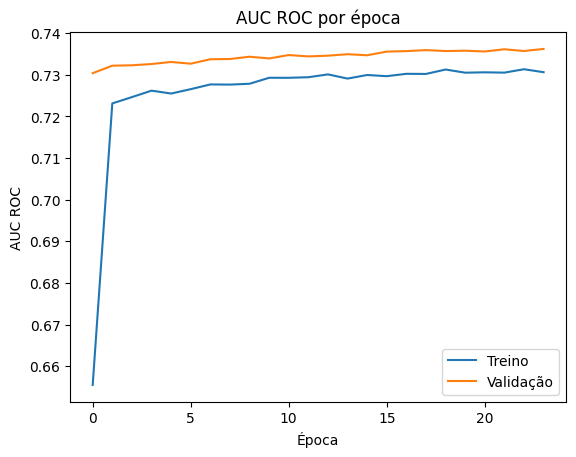

In [ ]:
view_score("AUC ROC", "auc_roc")

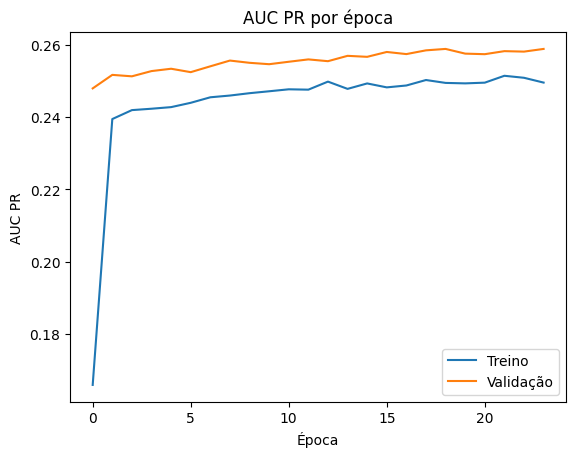

In [ ]:
view_score("AUC PR", "auc_pr")

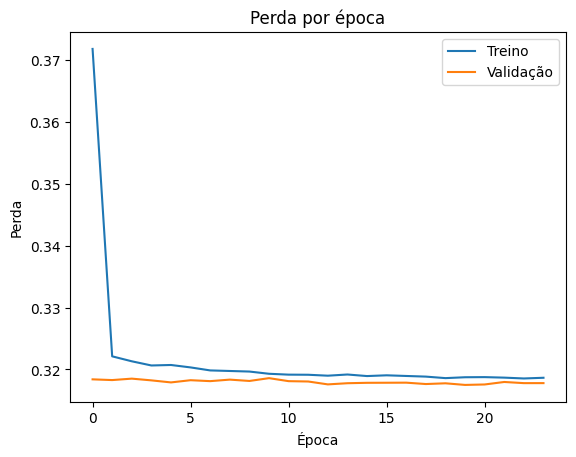

In [ ]:
view_score("Perda", "loss")

### Testando o modelo de CNN do zero

In [ ]:
def evaluate_model(y_true, y_pred):
  roc_auc_micro = roc_auc_score(y_true, y_pred, average="micro")
  roc_auc_macro = roc_auc_score(y_true, y_pred, average="macro")

  print("ROC AUC micro:", roc_auc_micro)
  print("ROC AUC macro:", roc_auc_macro)

  pr_auc_micro = average_precision_score(y_true, y_pred, average="micro")
  pr_auc_macro = average_precision_score(y_true, y_pred, average="macro")

  print("PR AUC micro:", pr_auc_micro)
  print("PR AUC macro:", pr_auc_macro)

In [ ]:
# raw_model = load_model('/content/best_model_raw_auc_pr_0.4228.keras')

In [ ]:
y_pred_test = raw_model.predict(test_generator, verbose=1)
y_true_test = test_generator.labels  # rótulos verdadeiros do conjunto de teste

8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 302ms/step


In [ ]:
evaluate_model(y_true_test, y_pred_test)

ROC AUC micro: 0.7395935021078739
ROC AUC macro: 0.5217047161259212
PR AUC micro: 0.2552276653062778
PR AUC macro: 0.14899017651419091


In [ ]:
# Binariza o retorno com um limiar de 0.5
y_pred_binary = (y_pred_test >= 0.5).astype(int)

F1-Micro: Soma todos os verdadeiros positivos / falsos positivos / falsos negativos e calcula o F1 global (útil se classes tem tamanhos diferentes).

F1-Macro: Calcula o F1 de cada classe e tira a média (todas as classes tem o mesmo peso).

In [ ]:
f1_macro = f1_score(y_true_test, y_pred_binary, average='macro')
f1_micro = f1_score(y_true_test, y_pred_binary, average='micro')

print(f"F1 macro: {f1_macro:.4f}")
print(f"F1 micro: {f1_micro:.4f}")

F1 macro: 0.0000
F1 micro: 0.0000


### Transferência de Aprendizado

In [ ]:
@tf.keras.utils.register_keras_serializable()
class ChannelAttention(Layer):
    def __init__(self, ratio=8, **kwargs):
        super(ChannelAttention, self).__init__(**kwargs)
        self.ratio = ratio
        self.avg_pool = GlobalAveragePooling2D() # Reduz a dimensionalidade, é uma camada que é utilizada após as camadas convolucionais
        self.max_pool = GlobalMaxPooling2D()

    def build(self, input_shape):
        # Camada densa de rede neural regulado pelo ratio
        self.fc1 = Dense(units=input_shape[-1]//self.ratio, activation='relu')
        self.fc2 = Dense(units=input_shape[-1], activation='sigmoid')

    def call(self, inputs):
        avg_out = self.avg_pool(inputs)
        max_out = self.max_pool(inputs)

        avg_out = self.fc2(self.fc1(avg_out))
        max_out = self.fc2(self.fc1(max_out))

        out = avg_out + max_out
        out = tf.expand_dims(tf.expand_dims(out, axis=1), axis=1)

        return inputs * out

class SpatialAttention(Layer):
    def __init__(self, kernel_size=7, **kwargs):
        super(SpatialAttention, self).__init__(**kwargs)
        self.conv2d = Conv2D(1, kernel_size, padding='same', activation='sigmoid')

    def call(self, inputs):
        avg_out = tf.reduce_mean(inputs, axis=-1, keepdims=True)
        max_out = tf.reduce_max(inputs, axis=-1, keepdims=True)
        concat = tf.concat([avg_out, max_out], axis=-1)
        return inputs * self.conv2d(concat)

In [ ]:
base_model = InceptionV3(input_shape=(HEIGHT, WIDTH, 3),
                        include_top=False, # include_top=False já remove as camadas finais (de classificação) automaticamente
                        weights='imagenet')

base_model.trainable = False

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Adições extras para a saída do modelo:

Foi adicionado uma **camada de atenção de canal**, onde irá permitir que a rede neural foque em canais de características mais relevantes, ignorando informações menos importantes. Assim como, logo após a camada de atenção foi adicionado uma camada de **atenção espacial** que permite a rede neural focar em onde essas características aparecem, isto é, em quais regiões da imagem o modelo deve olhar com mais peso.

A partir de pesquisas, foi descoberto que essa técnica também costuma melhorar o *recall* em problemas multilabel médicos.

Canal -> O que é importante (quais características/filtros merecem mais peso)
Espacial -> Onde é importante (quais regiões da imagem são relevantes)

Este tipo de técnica se chama **CBAM (Convolutional Block Attention Module)**.

In [ ]:
inputs = Input(shape=(HEIGHT, WIDTH, 3))

# Modelo base (InceptionV3)
x = base_model(inputs, training=False)

# Mecanismo de atenção (CBAM - Channel + Spatial Attention / Atenção de canal + Atenção Espacial)
x = ChannelAttention(ratio=8)(x) # Foca nos canais relevantes
x = SpatialAttention()(x) # Foca nas regiões espaciais mais importantes da imagem

x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
outputs = Dense(len(label_cols), activation='sigmoid')(x)

model = Model(inputs, outputs)

In [ ]:
model.compile(optimizer=Adam(learning_rate=1e-4), # 0.0001
              loss=BinaryCrossentropy(),
              metrics=[
                AUC(curve='ROC', name='auc_roc'),
                AUC(curve='PR', name='auc_pr')
              ]
          )

In [ ]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_auc_pr', patience=5, restore_best_weights=True, mode="max"),
    tf.keras.callbacks.ModelCheckpoint(monitor='val_auc_pr', mode='max', filepath='best_model_auc_pr_{val_auc_pr:.4f}.keras', save_best_only=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5)
]

In [ ]:
start_time = datetime.now()

history = model.fit(train_generator,
                    validation_data=val_generator,
                    callbacks=callbacks,
                    verbose=1,
                    epochs=100)

end_time = datetime.now()

elapsed_time = end_time - start_time

Epoch 1/100
578/578 ━━━━━━━━━━━━━━━━━━━━ 118s 167ms/step - auc_pr: 0.2002 - auc_roc: 0.6757 - loss: 0.3625 - val_auc_pr: 0.3510 - val_auc_roc: 0.7738 - val_loss: 0.2998 - learning_rate: 1.0000e-04
Epoch 2/100
578/578 ━━━━━━━━━━━━━━━━━━━━ 62s 107ms/step - auc_pr: 0.3411 - auc_roc: 0.7683 - loss: 0.3027 - val_auc_pr: 0.3822 - val_auc_roc: 0.7888 - val_loss: 0.2932 - learning_rate: 1.0000e-04
Epoch 3/100
578/578 ━━━━━━━━━━━━━━━━━━━━ 62s 107ms/step - auc_pr: 0.3649 - auc_roc: 0.7808 - loss: 0.2969 - val_auc_pr: 0.3975 - val_auc_roc: 0.7934 - val_loss: 0.2908 - learning_rate: 1.0000e-04
Epoch 4/100
578/578 ━━━━━━━━━━━━━━━━━━━━ 62s 108ms/step - auc_pr: 0.3817 - auc_roc: 0.7875 - loss: 0.2932 - val_auc_pr: 0.4030 - val_auc_roc: 0.7977 - val_loss: 0.2882 - learning_rate: 1.0000e-04
Epoch 5/100
578/578 ━━━━━━━━━━━━━━━━━━━━ 62s 107ms/step - auc_pr: 0.3978 - auc_roc: 0.7955 - loss: 0.2902 - val_auc_pr: 0.4060 - val_auc_roc: 0.7988 - val_loss: 0.2877 - learning_rate: 1.0000e-04
Epoch 6/100
578/578

In [ ]:
print(f'Tempo de treinamento: {elapsed_time}')

Tempo de treinamento: 0:19:25.874266


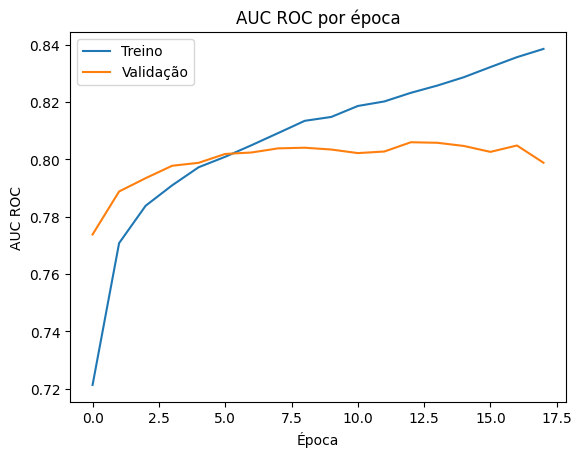

In [ ]:
view_score("AUC ROC", "auc_roc")

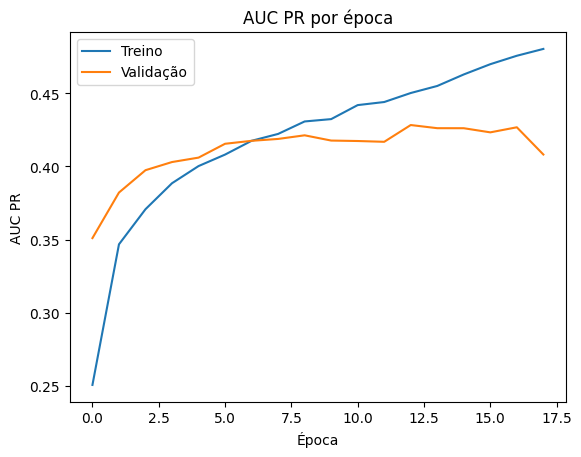

In [ ]:
view_score("AUC PR", "auc_pr")

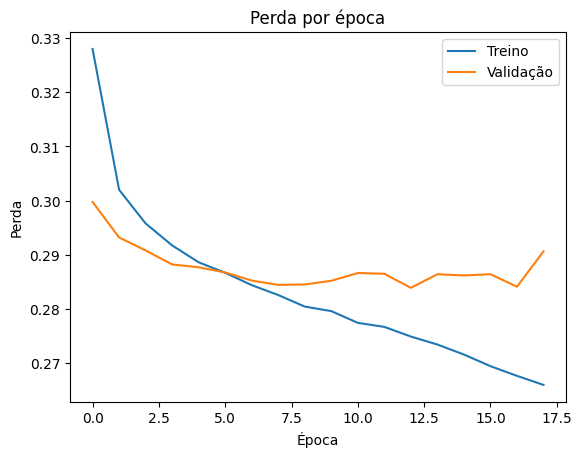

In [ ]:
view_score("Perda", "loss")

### Testando o modelo com transferência de aprendizado

In [ ]:
y_pred_test = model.predict(test_generator, verbose=1)
y_true_test = test_generator.labels  # rótulos verdadeiros do conjunto de teste

8/8 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step


In [ ]:
evaluate_model(y_true_test, y_pred_test)

ROC AUC micro: 0.8068520366473596
ROC AUC macro: 0.6773812551064289
PR AUC micro: 0.4488109318526593
PR AUC macro: 0.2553816768927465


In [ ]:
# Binariza o retorno com um limiar de 0.5
y_pred_binary = (y_pred_test >= 0.5).astype(int)

In [ ]:
f1_macro = f1_score(y_true_test, y_pred_binary, average='macro')
f1_micro = f1_score(y_true_test, y_pred_binary, average='micro')

print(f"F1 macro: {f1_macro:.4f}")
print(f"F1 micro: {f1_micro:.4f}")

F1 macro: 0.1164
F1 micro: 0.2985


### Salvando o melhor modelo

In [ ]:
ROOT_DIR = Path('/content')

# Adquire todos os modelos exportados
best_models = [f.name for f in ROOT_DIR.iterdir() if f.name.startswith("best_model_auc_pr_")]

# Adquire todos os valores AUC dos modelos exportados
aucs = []
for m in best_models:
  split = m.split('best_model_auc_pr_')
  auc = float(split[1].replace('.keras', ''))
  aucs.append(auc)

# Adquire maior valor de AUC
best_auc = max(aucs)

# Adquire o primeiro modelo que contem o valor do melhor AUC
best_model_name = next((n for n in best_models if str(best_auc) in n))
print("Melhor modelo:", best_model_name)

Melhor modelo: best_model_auc_pr_0.4283.keras


In [ ]:
origin_model_path = Path(os.path.join(ROOT_DIR, best_model_name))
destination_save_model_path = Path(os.path.join(ROOT_DIR, 'drive/MyDrive/Datasets/Models/CheXpert_CNN'))

origin_model_path, destination_save_model_path

(PosixPath('/content/best_model_auc_pr_0.4283.keras'),
 PosixPath('/content/drive/MyDrive/Datasets/Models/CheXpert_CNN'))

In [ ]:
# Garante que a pasta exista
destination_save_model_path.mkdir(parents=True, exist_ok=True)

Salva o modelo na pasta do Google Drive.

In [ ]:
shutil.copy(origin_model_path, destination_save_model_path / origin_model_path.name)

PosixPath('/content/drive/MyDrive/Datasets/Models/CheXpert_CNN/best_model_auc_pr_0.4283.keras')

Modelo treinado com acelerador A100 do Google Colab.